<a href="https://colab.research.google.com/github/amatsukami0420/AI_Lab_Assignments-CSC262/blob/main/LabTask_Min_Max_Alpha_Beta_Pruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NAME:** Muhammad Waleed Bin Anwar
# **REG NO:** FA24-BCS-110
# **SECTION:** 4C
[github link](https://github.com/amatsukami0420/AI_Lab_Assignments-CSC262)



# **TASK 1**

### **Q1: Implement this tree using min-max algorithm**
NOTE: Use Functions to implement rather than using a class

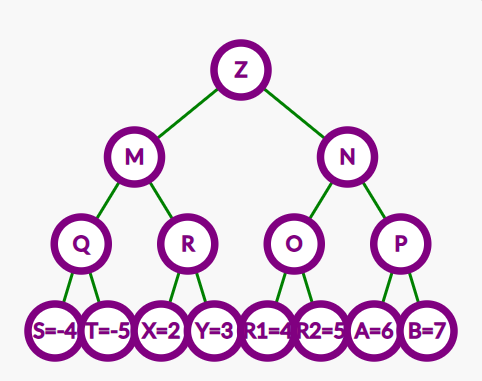

In [ ]:
graph_data = """
Z M
Z N
M Q
M R
Q S
Q T
R X
R Y
N O
N P
O R1
O R2
P A
P B
"""
terminal_values= {'S': -4, 'T': -5, 'X': 2, 'Y': 3, 'R1': 4, 'R2': 5, 'A': 6, 'B': 7}

In [ ]:
def build_graph(data):
    adj = {}
    for line in data.strip().split("\n"):
      u, v = line.split()
      if u not in adj: adj[u] = []
      if v not in adj: adj[v] = []
      adj[u].append(v)
      adj[v].append(u)
    return adj

In [ ]:
tree1 = build_graph(graph_data)

In [ ]:
def minimax(node, depth, is_maximizing, tree, terminals, visited):
    # If the node is a leaf/terminal, return its value
    if node in terminals:
        return terminals[node]

    visited.add(node)
    # Get children: nodes connected to current that haven't been visited (parent)
    children = [child for child in tree[node] if child not in visited]

    if not children:
        return terminals.get(node, 0)

    if is_maximizing:
        best_val = float('-inf')
        for child in children:
            value = minimax(child, depth + 1, False, tree, terminals, visited.copy())
            best_val = max(best_val, value)
        return best_val
    else:
        best_val = float('inf')
        for child in children:
            value = minimax(child, depth + 1, True, tree, terminals, visited.copy())
            best_val = min(best_val, value)
        return best_val

# Execution starting from 'Z' (Root)
# Sequence: Max (Z), Min (M, N), Max (Q, R, O, P), Min (S, T, X, Y, R1, R2, A, B)
root_node = 'Z'
result = minimax(root_node, 0, True, tree1, terminal_values, set())
print(f"The value of the root node '{root_node}' using Min-Max is: {result}")

The value of the root node 'Z' using Min-Max is: 5


### **20 Questions & Answers: Min-Max Algorithm Implementation**

1. **What is the purpose of the Min-Max algorithm?**
   It is a decision-making algorithm used in game theory and AI to find the optimal move for a player, assuming the opponent also plays optimally.

2. **Write the syntax of the `minimax` function used in the code.**
   `def minimax(node, depth, is_maximizing, tree, terminals, visited):`

3. **What does the `is_maximizing` boolean parameter represent?**
   It determines whether the current turn is for the Maximizer (True) trying to get the highest score, or the Minimizer (False) trying to get the lowest score.

4. **How are leaf nodes identified in this implementation?**
   By checking if the current `node` exists in the `terminals` dictionary: `if node in terminals: return terminals[node]`.

5. **Why is `visited.copy()` passed into the recursive call?**
   To ensure each recursive path has its own record of visited nodes, preventing interference between different branches of the tree exploration.

6. **What is the time complexity of the Min-Max algorithm?**
   O(b^d), where 'b' is the branching factor and 'd' is the depth of the tree.

7. **What is the space complexity of the Min-Max algorithm?**
   O(bd) or O(d) depending on the implementation, as it uses Depth-First Search (DFS).

8. **What role does the `build_graph` function play?**
   It converts a raw string of edge pairs into an adjacency list (dictionary) representing the tree structure.

9. **Explain the line `best_val = float('-inf')`.**
   It initializes the best value for the Maximizer to negative infinity so that any real score encountered will be higher.

10. **Explain the line `best_val = float('inf')`.**
   It initializes the best value for the Minimizer to infinity so that any real score encountered will be lower.

11. **In the graph data provided, which node is the Root?**
   Node 'Z'.

12. **What is the depth of the tree in this implementation?**
   The tree has a depth of 3 (from Root Z to terminal nodes like S or R1).

13. **How does the algorithm handle child nodes?**
   It filters the adjacency list to find nodes connected to the current node that have not been visited yet: `children = [child for child in tree[node] if child not in visited]`.

14. **What is the base case for the recursion?**
   When a terminal node is reached or a node has no unvisited children.

15. **What would happen if `is_maximizing` was set to False at the root?**
   The algorithm would calculate the result assuming the first player is a Minimizer, likely resulting in a different optimal value.

16. **How can the Min-Max algorithm be optimized?**
   By using Alpha-Beta pruning to eliminate branches that don't need to be searched.

17. **What type of data structure is `tree1`?**
   A Python Dictionary (Adjacency List).

18. **Write the code snippet that calculates the Maximizer's best move.**
   ```python\nvalue = minimax(child, depth + 1, False, tree, terminals, visited.copy())\nbest_val = max(best_val, value)\n```

19. **Write the code snippet that calculates the Minimizer's best move.**
   ```python\nvalue = minimax(child, depth + 1, True, tree, terminals, visited.copy())\nbest_val = min(best_val, value)\n```

20. **What is the final value of the root node 'Z' in this specific example?**
   The final value is 5.

# **TASK 2**

### **Q1: Apply Alpha-Beta Pruning on the following graph**

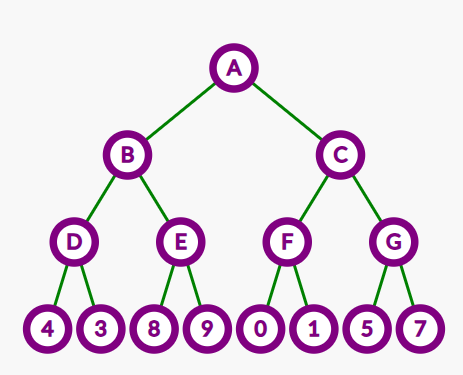

In [7]:
graph_data2 = """
A B
A C
B D
B E
C F
C G
D 4
D 3
E 8
E 9
F 0
F 1
G 7
G 5
"""

In [8]:
tree2 = build_graph(graph_data2)

In [9]:
def alpha_beta(node, depth, alpha, beta, is_maximizing, tree, visited):
    # Check if the node is a terminal value (numeric string in graph_data2)
    if node.isdigit():
        return int(node)

    visited.add(node)
    children = [child for child in tree.get(node, []) if child not in visited]

    if not children:
        # If it's a leaf node but not explicitly a number in our graph string
        return 0

    if is_maximizing:
        value = float('-inf')
        for child in children:
            value = max(value, alpha_beta(child, depth + 1, alpha, beta, False, tree, visited.copy()))
            alpha = max(alpha, value)
            if alpha >= beta:
                break  # Beta cutoff
        return value
    else:
        value = float('inf')
        for child in children:
            value = min(value, alpha_beta(child, depth + 1, alpha, beta, True, tree, visited.copy()))
            beta = min(beta, value)
            if beta <= alpha:
                break  # Alpha cutoff
        return value

# Execution for Tree 2 starting from 'A'
# Levels: Max (A), Min (B, C), Max (D, E, F, G)
root_node2 = 'A'
final_value = alpha_beta(root_node2, 0, float('-inf'), float('inf'), True, tree2, set())
print(f"The value of the root node '{root_node2}' using Alpha-Beta Pruning is: {final_value}")

The value of the root node 'A' using Alpha-Beta Pruning is: 4


### **20 Questions & Answers: Alpha-Beta Pruning Implementation**

1. **What is the primary advantage of Alpha-Beta pruning over standard Min-Max?**  
   It reduces the number of nodes evaluated in the search tree by 'pruning' branches that cannot possibly influence the final decision, improving efficiency.

2. **What does the `alpha` parameter represent?**  
   It represents the best (highest) value that the Maximizer is currently guaranteed to achieve.

3. **What does the `beta` parameter represent?**  
   It represents the best (lowest) value that the Minimizer is currently guaranteed to achieve.

4. **When does a 'Beta cutoff' occur in the code?**  
   When `alpha >= beta` during the Maximizer's turn, meaning the Minimizer already has a better option elsewhere, so we stop searching that branch.

5. **When does an 'Alpha cutoff' occur in the code?**  
   When `beta <= alpha` during the Minimizer's turn, meaning the Maximizer already has a better option elsewhere.

6. **How are terminal values handled in `tree2`?**  
   The code checks if the node string is a digit (`node.isdigit()`) and converts it to an integer.

7. **What is the time complexity of Alpha-Beta pruning in the best case?**  
   O(b^(d/2)), which effectively doubles the searchable depth compared to standard Min-Max.

8. **Does Alpha-Beta pruning change the final result compared to Min-Max?**  
   No, it always returns the same optimal value as standard Min-Max; it just does so more quickly.

9. **What role does `visited.copy()` play in the recursive calls?**  
   It prevents the path-finding logic from getting stuck in cycles while ensuring different branches don't share the same visit history.

10. **In `tree2`, what are the roles of nodes B and C?**  
    They act as Minimizer nodes (depth 1).

11. **What happens if a node has no children and isn't a digit?**  
    The function returns 0 as a default fallback value.

12. **Why is `float('-inf')` used for the initial `alpha`?**  
    To ensure that any real terminal value encountered will be larger than the starting alpha.

13. **Why is `float('inf')` used for the initial `beta`?**  
    To ensure that any real terminal value encountered will be smaller than the starting beta.

14. **What is the branching factor of `tree2`?**  
    The branching factor is 2 (each node has 2 children).

15. **What is the depth of `tree2`?**  
    The depth is 3 (Root A to the terminal values like 4, 3, 8, etc.).

16. **How does the code identify children of a node?**  
    It looks up the node in the adjacency list `tree` and filters out already visited nodes.

17. **What is the initial call to start the algorithm?**  
    `alpha_beta('A', 0, float('-inf'), float('inf'), True, tree2, set())`.

18. **In the Maximizer loop, how is `alpha` updated?**  
    `alpha = max(alpha, value)` after evaluating a child.

19. **In the Minimizer loop, how is `beta` updated?**  
    `beta = min(beta, value)` after evaluating a child.

20. **What was the final result for Root Node 'A'?**  
    The result was 4.